In [2]:
import re
import os
import pandas as pd
import numpy as np
from Bio import SeqIO
from datetime import datetime
from plotnine import *
import unicodedata
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
# Read in the metadata

In [4]:
# FILE = "./metadata/global-H5N5-A6-seq-n334-metadata.xlsx"
FILE = "./metadata/updated_metadata_cleaned_may2026.tsv"

In [5]:
# metadata = pd.DataFrame(pd.read_excel(FILE))
metadata = pd.DataFrame(pd.read_csv(FILE, sep = "\t"))

In [6]:
print(len(metadata))

365


In [7]:
# metadata_strains = metadata["newid"].to_list()
metadata_isolateid = metadata["Isolate_Id"].to_list()
# print(metadata_isolateid)

In [8]:
#Function: Read in the FASTA as a dataframe

def fasta_reader(path_to_fasta, output_name):
    fasta_data = []
    FASTANAME = path_to_fasta
        
    with open(FASTANAME) as f:
        header = ""
        sequence = ""
        for line in f:
            if line.startswith(">"):
                if header != "":
                    fasta_data.append({"header": header, "sequence": sequence})
                header = line.strip() 
                sequence = ""
            else:
                sequence += line.strip()
        fasta_data.append({"header": header, "sequence": sequence}) #last line 
        
    globals()[output_name] = pd.DataFrame(fasta_data)

    return

In [9]:
# fasta_reader("./alignments/updated_all_A6_2025_12_16_concat_genome_aln_n342.fasta", "fasta")
# fasta_reader("./alignments/A6_concat_genome_may2026_n364.fasta", "fasta")
fasta_reader("./alignments/A6_concat_genome_aligned_may2026_n362.fasta", "fasta")

In [10]:
# Function: generate an isolate ID for each strain to match to metadata

def pull_fasta_id(fasta):

    fasta["newid"] = fasta["header"].str.split(">", expand = True)[1]

    fasta["isolate_id"] = fasta["newid"].str.split("|", expand = True)[0]

    # Some new strains do not have an EPI isolate, and so I used a different code in the metadata
    fasta.loc[fasta["newid"].str.contains("EPI_ISL_TBD"), "isolate_id"] = fasta["newid"].str.split("/", expand = True)[3] 

    return(fasta)

In [11]:
fasta_upt = pull_fasta_id(fasta)

In [12]:
fasta_ids = fasta_upt["isolate_id"].to_list()

In [13]:
# CHECKING: Compare fasta strains and metadata strains

no_match = [] # strains that are in metadata but not fasta

for i in metadata_isolateid:
    if i in fasta_ids:
        pass
    else:
        no_match.append(i)

print(len(no_match))
print(no_match)

3
['EPI_ISL_19755851', 'EPI_ISL_19712970', '24-000869-004']


In [14]:
# Function: standardize metadata newid (because it currently does not match the FASTA)

def standardize_newid(string):

    newid = string

    newid = newid.strip()
    newid = newid.replace(" ", "_")

    return(newid)

In [15]:
# Some standardizing

metadata_upt = metadata.copy()
metadata_upt["newid"] = metadata_upt["newid"].apply(standardize_newid)
metadata_upt["Location"] = metadata_upt["Location"].str.strip()
metadata_upt["host"] = metadata["host"].str.replace(" ", "_")

In [16]:
fine_scale_locations = pd.DataFrame(set(metadata["Location"])).rename({0:"full_location"}, axis = 1)

In [17]:
# Had to remove some weirdo accented characters
fine_scale_locations["full_location"] = (fine_scale_locations["full_location"].apply(lambda x: unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8") if isinstance(x, str) else x))

In [18]:
def finding_locations(df):

    df_new = df.copy()
    df_new["continent"] = None
    df_new["country"] = None
    df_new["state/province"] = None
    df_new["county/town"] = None
    df_new["municipality"] = None

    for index, row in df_new.iterrows():
        full_location = row["full_location"]
        parts = full_location.split(" / ")

        if len(parts) == 2:
            df_new.at[index, "continent"] = parts[0]
            df_new.at[index, "country"] = parts[1]
            df_new.at[index, "state/province"] = None
            df_new.at[index, "county/town"] = None
            df_new.at[index, "municipality"] = None
        elif len(parts) == 3:
            df_new.at[index, "continent"] = parts[0]
            df_new.at[index, "country"] = parts[1]
            df_new.at[index, "state/province"] = parts[2]
            df_new.at[index, "county/town"] = None
            df_new.at[index, "municipality"] = None
        elif len(parts) == 4:
            df_new.at[index, "continent"] = parts[0]
            df_new.at[index, "country"] = parts[1]
            df_new.at[index, "state/province"] = parts[2]
            df_new.at[index, "county/town"] = parts[3]
            df_new.at[index, "municipality"] = None
        elif len(parts) == 5:
            df_new.at[index, "continent"] = parts[0]
            df_new.at[index, "country"] = parts[1]
            df_new.at[index, "state/province"] = parts[2]
            df_new.at[index, "county/town"] = parts[3]
            df_new.at[index, "municipality"] = parts[4]
        else:
            print(f"more parts in {full_location}")

    return(df_new)

In [19]:
fine_scale_locations_upt = finding_locations(fine_scale_locations)

In [20]:
print(fine_scale_locations_upt)

                                         full_location      continent  \
0    North America / Canada / Prince Edward Island ...  North America   
1    North America / Canada / Nova Scotia / Metegha...  North America   
2    Europe / Norway / Sogn og Fjordane Fylke / Ask...         Europe   
3          Europe / Svalbard and Jan Mayen / Jan Mayen         Europe   
4             Europe / Norway / Nordland Fylke / Somna         Europe   
..                                                 ...            ...   
107  Europe / Norway / Troms Fylke / Storfjord / Sk...         Europe   
108  Europe / Russian Federation / Republic of Kalm...         Europe   
109              Europe / Norway / Troms Fylke / Senja         Europe   
110  North America / Canada / Nova Scotia / Port Ca...  North America   
111  Europe / Netherlands / Provincie Noord-Holland...         Europe   

                    country           state/province      county/town  \
0                    Canada     Prince Edward Isla

In [21]:
# Update the current CSV with any new fine-scale locations

locations_csv = pd.read_csv("./metadata/fine_scale_locations.csv", sep = ',')
print(len(locations_csv["full_location"]))

new_locations = fine_scale_locations_upt["full_location"][~fine_scale_locations_upt["full_location"].isin(locations_csv["full_location"])]
print(len(new_locations), new_locations)

# If new locations, add them on
# updated_locations_csv = pd.concat([locations_csv, new_locations])
# updated_locations_csv.to_csv("./metadata/fine_scale_locations.csv", sep = ',')

111
1 104    North America / United States / Massachusetts 
Name: full_location, dtype: str


In [22]:
locations_dict = locations_csv.set_index("full_location").to_dict(orient="index")

In [23]:
# Read in the list of hosts and make sure there aren't hosts in the metadata that aren't in the list

hosts_csv = pd.read_csv("./metadata/host_lists.csv", sep = ',')
print(metadata_upt["host"].loc[~metadata_upt["host"].isin(hosts_csv["host"])]) # Are there any hosts in the metadata that are not in the hosts_csv

Series([], Name: host, dtype: str)


In [24]:
# scav: scavengers
# bdpr: bird of prey
# mammal: mammal
# seab: seabird
# gds: geese, ducks, and seaducks
# grdbd: ground birds

In [25]:
# Turn into a dictionary

hosts_dict = hosts_csv.set_index("host").to_dict(orient = "index")

In [26]:
def assigning_host_traits(metadata, locations, hosts):

    # Assign discrete trait 1 (continent/region) 
    # Assign state/province for sequences from North America, and country for sequences from Europe and Asia
    metadata["discrete-region"] = metadata["Location"].str.strip().map(lambda location: locations.get(location, {}).get("new-discrete-phylo"))
    metadata["latlong_type"] = metadata["Location"].str.strip().map(lambda location: locations.get(location, {}).get("latlong_type"))
    print(metadata["latlong_type"].value_counts())

    # Assign discrete trait 2 (host grouping)
    # See comment above for assignments
    metadata["host-group"] = metadata["host"].map({k: v["host-group"] for k, v in hosts.items()})

    # Assign continuous trait (latitude and longitude)
    metadata["lat"] = metadata["Location"].map(lambda location: locations.get(location, {}).get("latitude"))
    metadata["long"] = metadata["Location"].map(lambda location: locations.get(location, {}).get("longitude"))

    # Generate trait TSVs
    keep_discrete = ["newid", "discrete-region"]
    keep_host = ["newid", "host-group"]
    keep_continuous = ["newid", "lat", "long"]

    discrete_phylo_trait = metadata.loc[0:, keep_discrete]
    print(discrete_phylo_trait[discrete_phylo_trait["discrete-region"].isna()]) # These are sequences whose discrete-region I have but cannot assign yet (Norway, Alaska, Ohio)
    host_trait = metadata.loc[0:, keep_host]
    cont_phylo_trait = metadata.loc[0:, keep_continuous]

    # Remove any unknown locations (and 24-000869-004 great black-backed gull because it has no NA sequence)
    unknowns = metadata.loc[metadata["discrete-region"] == "unknown"] # These are sequences whose region is generic "United States" - these should be removed
    print(unknowns["Isolate_Name"])
    no_na_seq = metadata.loc[metadata["Isolate_Id"] == "24-000869-004"]
    remove = pd.concat([unknowns, no_na_seq])
    print(f"Removing {len(remove)} sequences for missing sequences or metadata")

    discrete_phylo_trait = discrete_phylo_trait[~discrete_phylo_trait["newid"].isin(remove["newid"])]
    host_trait = host_trait[~host_trait["newid"].isin(remove["newid"])]
    cont_phylo_trait = cont_phylo_trait[~cont_phylo_trait["newid"].isin(remove["newid"])]

    # Rename columns (I didn't do this earlier because of repeat column names but Baltic HATES trait names with hyphens
    discrete_phylo_trait = discrete_phylo_trait.rename({"discrete-region":"region"}, axis = 1)
    host_trait = host_trait.rename({"host-group":"host"}, axis = 1)

    print(len(discrete_phylo_trait))
    print(len(host_trait))
    print(len(cont_phylo_trait))

    return(discrete_phylo_trait, host_trait, cont_phylo_trait)

In [27]:
discrete_phylo_trait, host_trait, cont_phylo_trait = assigning_host_traits(metadata_upt, locations_dict, hosts_dict)

latlong_type
country           187
county_town       161
state_province     14
unknown             2
Name: count, dtype: int64
                                                newid discrete-region
70  EPI_ISL_19510887|A/White-tailed_eagle/Norway/2...             NaN
305      A/american crow/USA/003298-003/2025
307    A/red-tailed hawk/USA/001719-002/2025
Name: Isolate_Name, dtype: str
Removing 3 sequences for missing sequences or metadata
362
362
362


In [27]:
discrete_phylo_trait.to_csv("./metadata/h5n5_discrete_phylogeography.tsv", sep ='\t', index = False)

In [27]:
host_trait.to_csv("./metadata/h5n5_discrete_host.tsv", sep ='\t', index = False)

In [28]:
cont_phylo_trait.to_csv("./metadata/h5n5_continuous_phylogeography.tsv", sep ='\t', index = False)

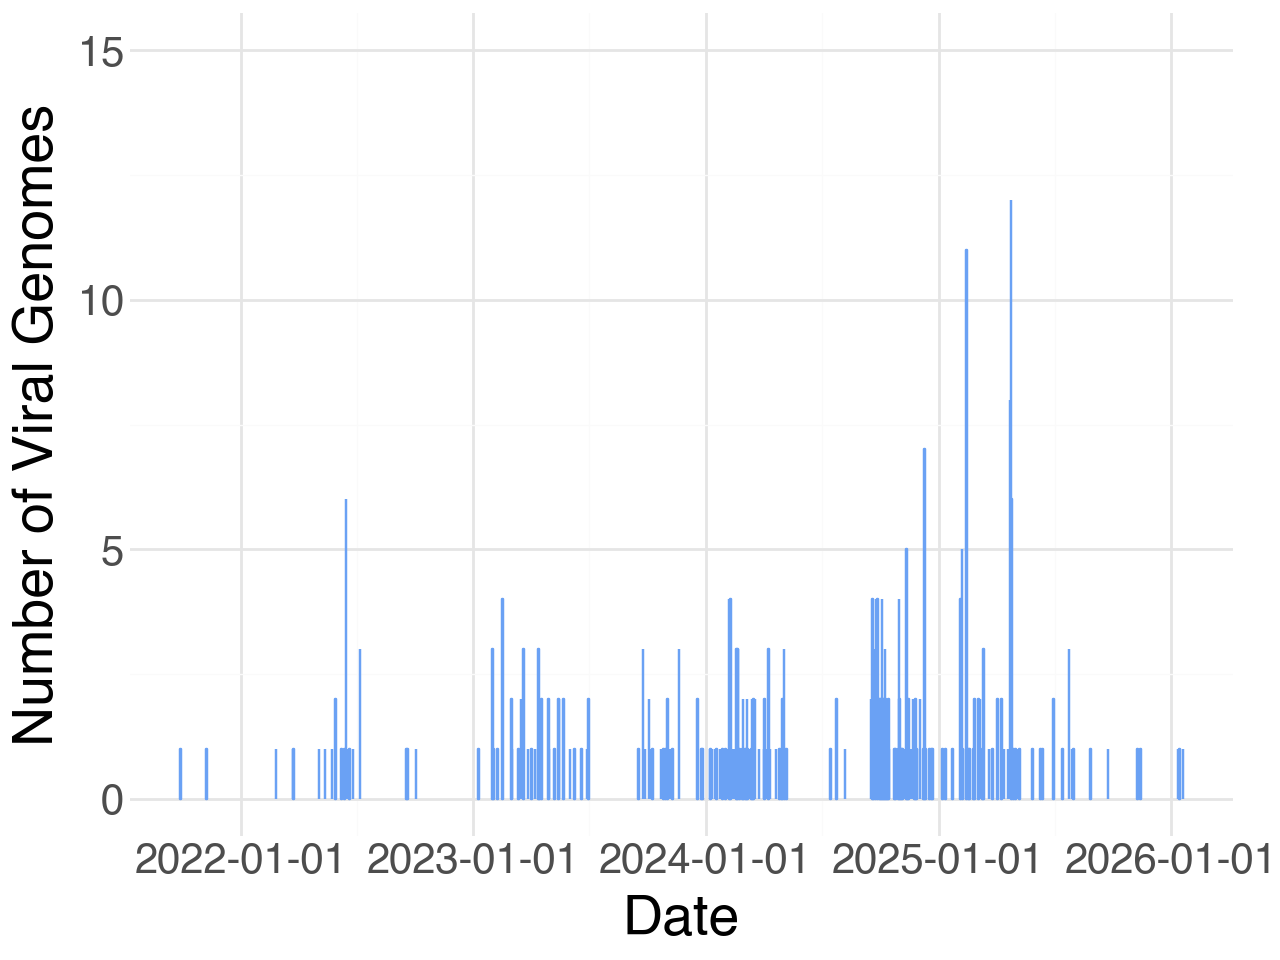

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 9 values. 10 were requested from it.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 9 values. 10 were requested from it.


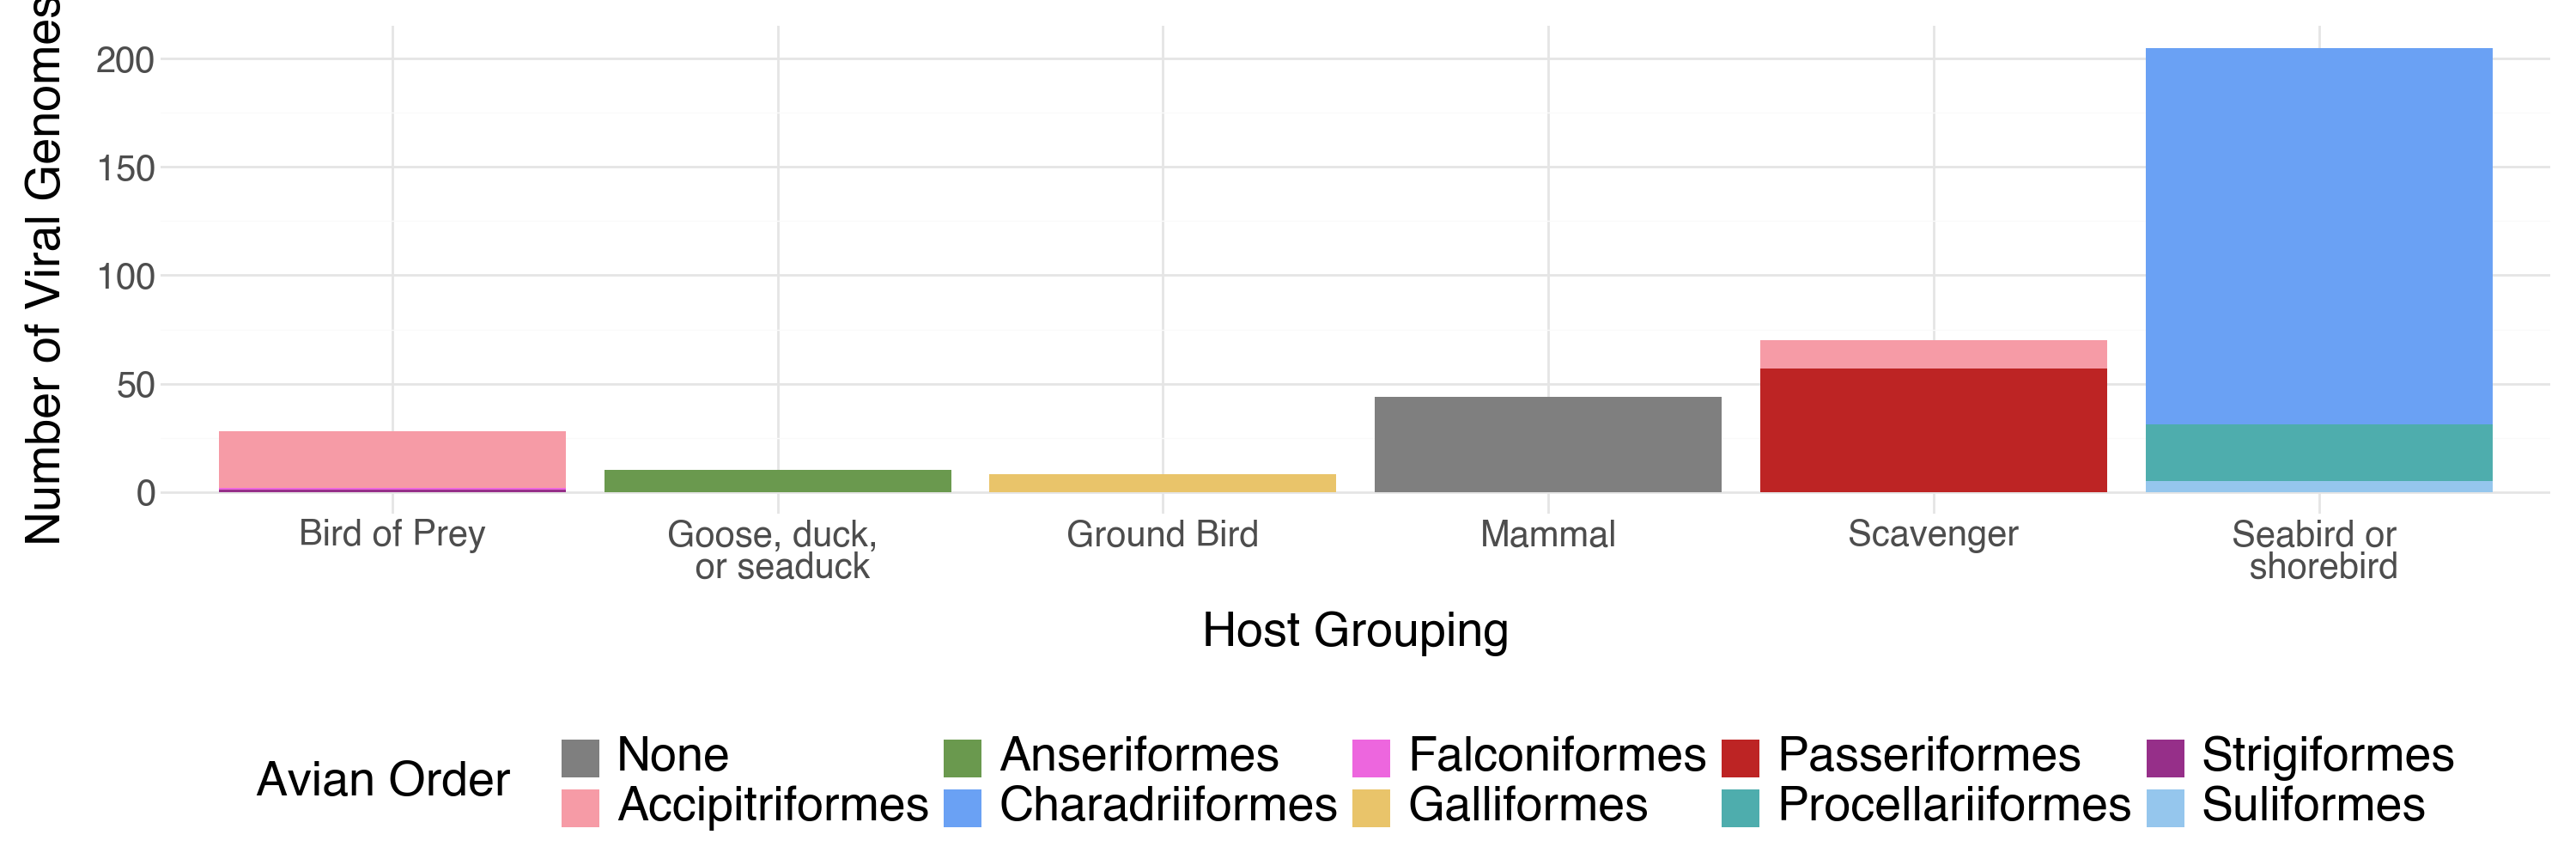

In [28]:
# I want to do some metadata plotting

metadata["Collection_datetime"] = metadata["Collection_Date"].astype(str) # Convert date to a string
metadata["Collection_datetime"] = metadata["Collection_datetime"].apply(lambda x: x + ".07.01" if len(x) == 4 else x) # If you just have a year, assign it to July 1 to plot
metadata["Collection_datetime"] = pd.to_datetime(metadata["Collection_datetime"]) # Make the datetime column an actual datetime object


# Samples over time
over_time = (
    ggplot(metadata, aes(x = "Collection_datetime"))
    + geom_col(stat = "count", color = "#6aa1f4")
    + labs(x = "Date", y = "Number of Viral Genomes")
    + theme_minimal()
    + ylim(0,15)
    + theme(legend_text=element_text(size=24), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=15))
)

# Samples per location, colored by continent
metadata["country"] = metadata["Location"].str.split("/", expand = True)[1]
metadata["country_labels"] = metadata["country"].str.strip().str.replace(" ", "\n")

per_location = (
    ggplot(metadata, aes(x = "country_labels", fill = "continent"))
    + geom_col(stat = "count")
    + labs(x = "Country", y = "Number of Viral Genomes", fill = "Continent")
    + scale_fill_manual({"Asia":"#b09a6e", "Europe":"#ffaaaa", "North America":"#95b8d1"})
    + theme_minimal()
    + theme(axis_text_x = element_text(rotation = 0, size = 10), figure_size = (20, 5), legend_text=element_text(size=20), 
            axis_title_x = element_text(size = 20), legend_title = element_text(size = 20), axis_title_y = element_text(size = 20), 
            text=element_text(size=15), legend_direction="horizontal", legend_position="bottom")
)

# Samples per host type
metadata["Wild bird order"] = metadata["Wild bird order"].str.lower()
metadata["host-group"] = metadata["host"].str.replace(" ", "_").map({k: v["host-group"] for k, v in hosts_dict.items()}) # I did this for the metadata earlier but now I want to do this for plotting
metadata["host-group_labels"] = metadata["host-group"].map({"bdpr":"Bird of Prey", "gds":"Goose, duck, \n or seaduck", "grdbd":"Ground Bird", "mammal":"Mammal", "scav":"Scavenger", "seab":"Seabird or \n shorebird"})
metadata.loc[metadata["host-group"] == "grdbd", "Wild bird order"] = "galliformes" # The domestic birds don't have a wild bird order (obviously), but they are technically galliformes
metadata.loc[metadata["Wild bird order"].isna(), "Wild bird order"] = "None"

per_host_type = (
    ggplot(metadata, aes(x = "host-group_labels", fill = "Wild bird order"))
    + geom_col(stat = "count")
    + labs(x = "Host Grouping", y = "Number of Viral Genomes", fill = "Avian Order")
    # + scale_fill_manual(values = {"domestic_avian":"#e9c46a", "human":"#000000", "nonhuman_mammal":"#a874d2", "wild_avian":"#6aa1f4"}, 
    #                     labels = {"domestic_avian":"Domestic Bird", "human":"Human", "nonhuman_mammal":"Non-human Mammal", "wild_avian":"Wild Bird"})
    # + scale_fill_manual(values = {"bdpr":"#f69ba6", "gds":"#6a994e", "grdbd":"#e9c46a", "mammal":"#a874d2", "scav":"#923e4d", "seab":"#6aa1f4"}, 
                        # labels = {"bdpr":"Bird of Prey", "gds":"Goose, duck, or seaduck", "grdbd":"Ground Bird", "mammal":"Mammal", "scav":"Scavenger", "seab":"Seabird or shorebird"})
    + scale_fill_manual(values = {"accipitriformes":"#f69ba6", "anseriformes":"#6a994e", "charadriiformes":"#6aa1f4", "falconiformes":"#ED66DE", 
                         "passeriformes":"#BD2424", "procellariiformes":"#4EADAD", "strigiformes":"#962F89", "suliformes":"#95C6ED", "galliformes":"#e9c46a"},
                        labels = {"accipitriformes":"Accipitriformes", 
                                  "anseriformes":"Anseriformes", 
                                  "charadriiformes":"Charadriiformes", 
                                  "falconiformes":"Falconiformes", 
                                  "passeriformes":"Passeriformes", 
                                  "procellariiformes":"Procellariiformes", 
                                  "strigiformes":"Strigiformes", 
                                  "suliformes":"Suliformes", 
                                  "galliformes":"Galliformes",
                                 "none":"None"})
    + theme_minimal()
    + theme(axis_text_x = element_text(rotation = 0), figure_size = (15, 5), legend_text=element_text(size=20), 
            axis_title_x = element_text(size = 20), legend_title = element_text(size = 20), axis_title_y = element_text(size = 20), 
            text=element_text(size=15), legend_direction="horizontal", legend_position="bottom")
)

# print(metadata["Wild bird order"].value_counts())

over_time.show()
# per_location.show()
per_host_type.show()

# print(metadata["host_type"].value_counts())
# print(metadata["country"].value_counts())
# print(metadata["Collection_Date"].astype(str).str.split("-", expand = True)[0].value_counts())

In [37]:
over_time.save("./metadata/metadata_over_time.png", format = "png", dpi = 750)
# per_location.save("./metadata/metadata_per_location.png", format = "png", dpi = 750)
per_host_type.save("./metadata/metadata_per_host.png", format = "png", dpi = 750)
# per_host_type.save("./metadata/metadata_per_host2.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./metadata/metadata_over_time.png
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 15 x 5 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./metadata/metadata_per_host.png
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 9 values. 10 were requested from it.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_fill_manual can return a maximum 

In [56]:
# Function: generate a dataframe of the number of sequences at each point, and the lat/long for mapping
def metadata_to_points(df, dictionary):

    # metadata["country"] = metadata["Location"].map(lambda location: dictionary.get(location, {}).get("country"))
    # metadata["latitude"] = metadata["Location"].map(lambda location: dictionary.get(location, {}).get("latitude"))
    # metadata["longitude"] = metadata["Location"].map(lambda location: dictionary.get(location, {}).get("longitude"))
    metadata["discrete-phylo"] = metadata["Location"].str.strip().map(lambda location: dictionary.get(location, {}).get("new-discrete-phylo"))

    points = pd.DataFrame(metadata["discrete-phylo"].value_counts()).reset_index()

    lookup_lat = {values["new-discrete-phylo"]: values["latitude"] for values in dictionary.values()} 
    lookup_long = {values["new-discrete-phylo"]: values["longitude"] for values in dictionary.values()}
    lookup_continent = {values["new-discrete-phylo"]: values["continent"] for values in dictionary.values()}
    
    # NAm = ["Canada", "United States"]
    assign_by_hand = ["north-canada", "east-canada", "northeast-us", "northwest-us", "unknown"]

    print(points["count"].loc[points["discrete-phylo"] == "unknown"])

    for idx, row in points.iterrows():
        region = row["discrete-phylo"]
        if region not in assign_by_hand:
            points.at[idx, "latitude"] = lookup_lat[region]
            points.at[idx, "longitude"] = lookup_long[region]
            points.at[idx, "continent"] = lookup_continent[region]
        elif region in assign_by_hand: # all coordinates below sourced from Wikipedia > Google Earth
            if "east-canada" in region:
                points.at[idx, "latitude"] = "50.216667" # Sept-Iles, QC (decided by eye)
                points.at[idx, "longitude"] = "-66.383333" # Sept-Iles, QC (decided by eye)
                points.at[idx, "continent"] = lookup_continent[region]
            if "north-canada" in region:
                points.at[idx, "latitude"] = "64.333333" # Southampton Island, Nunavut
                points.at[idx, "longitude"] = "-84.666667" # Southampton Island, Nunavut
                points.at[idx, "continent"] = lookup_continent[region]
            if "northeast-us" in region:
                points.at[idx, "latitude"] = "42.333333" # Northampton, MA (where I went to college, decided by nostalgia and eye)
                points.at[idx, "longitude"] = "-72.65" # Northampton, MA (where I went to college, decided by nostalgia and eye)
                points.at[idx, "continent"] = lookup_continent[region]
            if "northwest-us" in region:
                points.at[idx, "latitude"] = "47.603889" # Seattle, WA (decided by eye)
                points.at[idx, "longitude"] = "-122.33"
                points.at[idx, "continent"] = lookup_continent[region]
            if "unknown" in region: # These two only have "United States" as the location, so they're getting lumped in with northeast-us
                points.loc[points["discrete-phylo"] == "northeast-us", "count"] += 2 # add the number of unknowns 
            # if "Canada" in country:
            #     points.at[idx, "latitude"] = "57.97498" # As per Apple Maps
            #     points.at[idx, "longitude"] = "-101.98178" # As per Apple Maps
            #     points.at[idx, "continent"] = lookup_continent[country]
            # elif "United States" in country:
            #     points.at[idx, "latitude"] = "39.810278" # Lebanon, KS
            #     points.at[idx, "longitude"] = "-98.557222" # Lebanon, KS
            #     points.at[idx, "continent"] = lookup_continent[country]
        else:
            print("unknown")

    points_final = points[points["discrete-phylo"] != "unknown"] # Now drop the unknowns
    
    return(points_final)

EPSG:4326
6    2
Name: count, dtype: int64


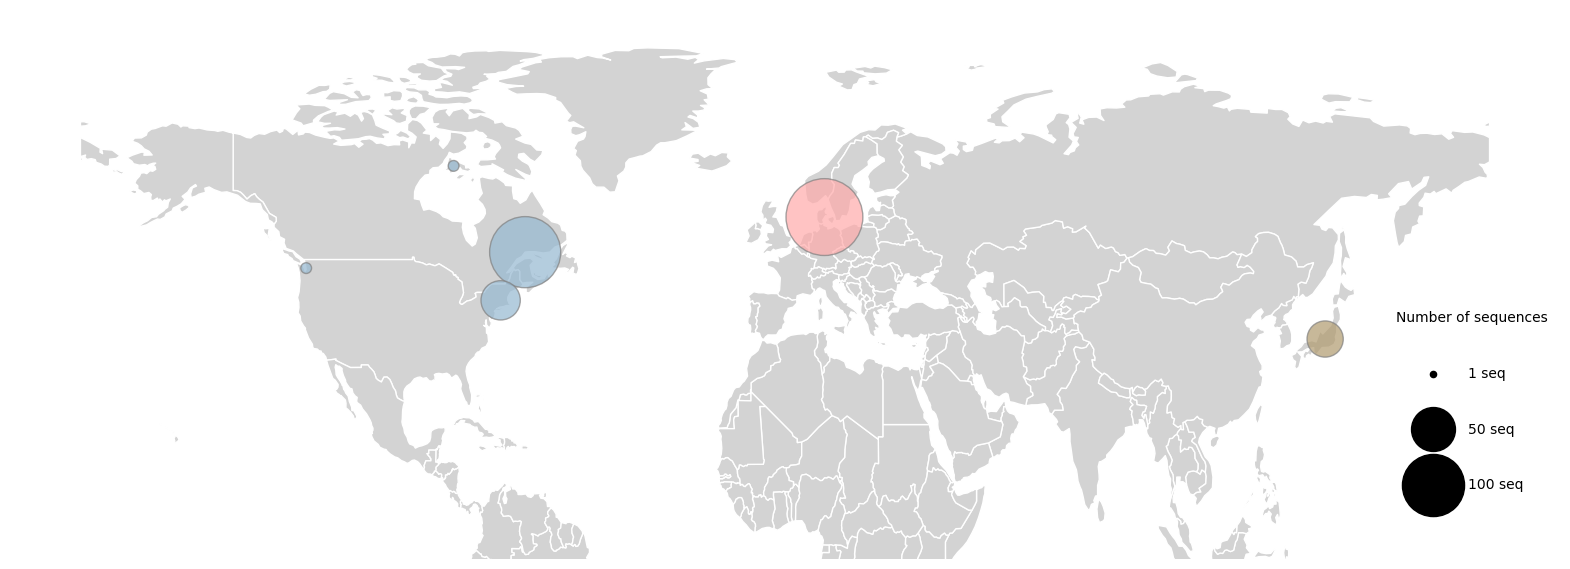

In [60]:
# Chat GPT helped a lot with this figure, especially the matplotlib plotting

path_to_shapefile = "./ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
world_gdf = gpd.read_file(path_to_shapefile)
print(world_gdf.crs)

fig, ax = plt.subplots(figsize=(20, 20))

# gdf_north = world_gdf[world_gdf.geometry.y > 25]
world_gdf.plot(ax=ax,color="lightgrey",edgecolor="white")

points = metadata_to_points(metadata, locations_dict)
gdf_points = gpd.GeoDataFrame(points,geometry=gpd.points_from_xy(points["longitude"], points["latitude"]),crs="EPSG:4326") # The basis for this line was provided by ChatGPT

# ChatGPT also suggested this line for adjusting bubble sizes
gdf_points["plot_size"] = gdf_points["count"] * 20

# def color_func(i)
#     for row in gdf_points.itterrows():
#         colors_dict = {"Asia":"#b09a6e", "Europe":"#ffaaaa", "North America":"#95b8d1"}
#         lambda i: colors_dict.get(row["continent"], 'grey')

continent_colors = {"Asia":"#b09a6e", "Europe":"#ffaaaa", "North America":"#95b8d1"}

gdf_points.plot(ax=ax, markersize=gdf_points["plot_size"], color=gdf_points["continent"].map(continent_colors), alpha=0.7, edgecolors="grey", label = (gdf_points["plot_size"] / 20))

# ChatGPT helped me make a matplotlib legend manually
sizes = [1, 50, 100]  # pick representative "count" values
handles = [plt.scatter([], [], s=s * 20, color="black", alpha=1, edgecolors="black") for s in sizes]
labels = [f"{s} seq" for s in sizes]
ax.legend(handles, labels, title="Number of sequences", loc="lower right", bbox_to_anchor=(1, 0.1), labelspacing=3, frameon=False, handletextpad=1.5)


ax.set_axis_off()
ax.set_ylim(0, 90)

plt.savefig(fname = './metadata/metadata_per_location.png', dpi=750)
plt.show()

In [ ]:
# Everything below is deprecated but may someday be handy

In [77]:
print(set(fine_scale_locations_upt["country"]))
print(set(fine_scale_locations_upt["state/province"].loc[fine_scale_locations_upt["continent"] == "North America"]))

{'Finland', 'United Kingdom', 'Belgium', 'Canada', 'Germany', 'Japan', 'Russian Federation', 'United States', 'Greenland', 'Netherlands', 'Norway', 'Svalbard and Jan Mayen', 'Iceland'}
{'Quebec', 'Washington', 'Nunavut', 'Nova Scotia', None, 'Prince Edward Island', 'New Brunswick', 'Massachusetts', 'Maine', 'Newfoundland and Labrador', 'Ontario'}


In [96]:
region_dict1 = {'Finland':'north-europe', 
               'United Kingdom':'west-europe', 
               'Belgium':'west-europe',  
               'Germany':'west-europe', 
               'Japan':'japan', 
               'Russian Federation':'east-europe', 
               'Greenland':'west-europe', 
               'Netherlands':'west-europe', 
               'Norway':'north-europe', 
               'Svalbard and Jan Mayen':'north-europe', 
               'Iceland':'west-europe'
               }

region_dict2 = {'Quebec':'west-canada', 
                'Washington':'pacific-northwest', # Could combine with Nunavut to be "other_northamerica"
                'Nunavut':'north-canada', # Could combine with Washington to be "other_northamerica"
                'Nova Scotia':'west-canada', 
                'Prince Edward Island':'west-canada', 
                'New Brunswick':'west-canada', 
                'Massachusetts':'new-england', 
                'Maine':'new-england', 
                'Newfoundland and Labrador':'west-canada', 
                'Ontario':'west-canada'
               }

In [104]:
def discrete_phylogeography(df, region_dict2):
    
    NAm = ["Canada", "United States"]

    df["discrete-phylo"] = df["continent"].str.lower().str.strip()
    df.loc[df["country"].isin(NAm), "discrete-phylo"] = df["state/province"].map(region_dict2).fillna("unknown")

    return(df)

In [105]:
fine_scale_locations_upt = discrete_phylogeography(fine_scale_locations_upt, region_dict2)

In [77]:
print(set(fine_scale_locations_upt["country"]))
print(set(fine_scale_locations_upt["state/province"].loc[fine_scale_locations_upt["continent"] == "North America"]))

{'Finland', 'United Kingdom', 'Belgium', 'Canada', 'Germany', 'Japan', 'Russian Federation', 'United States', 'Greenland', 'Netherlands', 'Norway', 'Svalbard and Jan Mayen', 'Iceland'}
{'Quebec', 'Washington', 'Nunavut', 'Nova Scotia', None, 'Prince Edward Island', 'New Brunswick', 'Massachusetts', 'Maine', 'Newfoundland and Labrador', 'Ontario'}


In [97]:
def continuous_phylogeography(df, region_dict2):
    
    NAm = ["Canada", "United States"]

    df["coordinates"] = df["continent"].str.lower().str.strip()
    df.loc[df["country"].isin(NAm), "discrete-phylo"] = df["state/province"].map(coord_dict).fillna("unknown")
    
    return(df)

In [98]:
fine_scale_locations_upt = discrete_phylogeography(fine_scale_locations_upt, region_dict2)

In [54]:
host_dict = {"Anseriformes":"anser",
            "Charadriiformes":"shrbrd",
            "Accipitriformes":"bird-of-prey",
            "Passeriformes":"passer",
            "Procellariiformes":"shrbrd",
            "Suliformes":"shrbrd",
            "Falconiformes":"bird-of-prey",
            "Strigiformes":"bird-of-prey",
            }

nan_dict = {"domestic_avian":"poultry",
            "nonhuman_mammal":"mammal",
            "human":"mammal"
           }